Iter  | A        | B        | C        | D        | E       
------------------------------------------------------------
1     | 0.0667 | 0.3667 | 0.2000 | 0.1667 | 0.2000
6     | 0.0944 | 0.2657 | 0.2713 | 0.1750 | 0.1935
11    | 0.0920 | 0.2746 | 0.2708 | 0.1858 | 0.1769
16    | 0.0904 | 0.2717 | 0.2740 | 0.1802 | 0.1838
21    | 0.0911 | 0.2732 | 0.2722 | 0.1825 | 0.1810
26    | 0.0908 | 0.2725 | 0.2730 | 0.1815 | 0.1822
30    | 0.0909 | 0.2726 | 0.2728 | 0.1817 | 0.1820


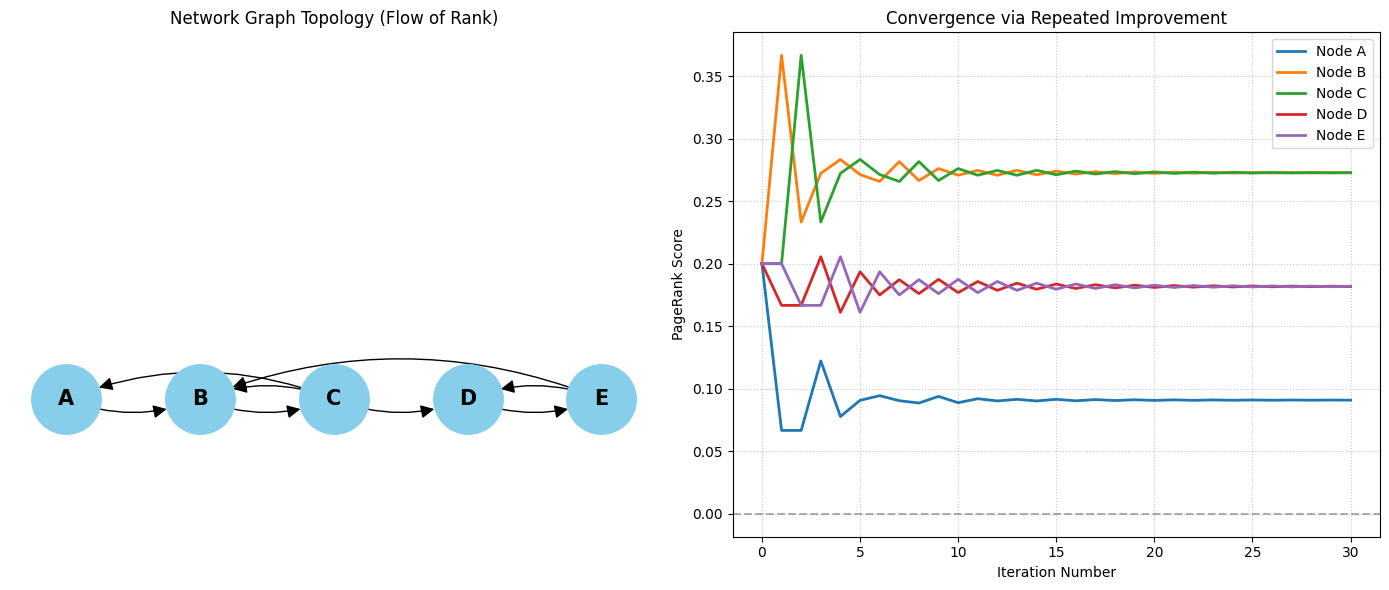

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# STEP 1: DEFINE THE SYSTEM PARAMETERS
# ==========================================
# Definition: PageRank works on the principle that a node is important if
# important nodes point to it. The score is distributed evenly among out-links.
# Formula: PR(A) = Sum( PR(neighbor) / OutDegree(neighbor) )

nodes = ['A', 'B', 'C', 'D', 'E']
num_nodes = len(nodes)

# Initial values from your image table: 1/5 for each node
# Definition: Initial Rank is a uniform distribution where every node starts
# with equal "mass" or probability.
ranks = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# To track convergence over time for visualization
history = [ranks.copy()]

# ==========================================
# STEP 2: THE REPEATED IMPROVEMENT FUNCTION
# ==========================================
def update_ranks(current_ranks):
    """
    Applies the specific update rules derived from your image graph:
    A = C/3
    B = A + C/3 + E/2 (Note: Graph shows C points to A, B, and D)
    C = B
    D = C/3 + E/2
    E = D
    """
    A, B, C, D, E = current_ranks

    # These formulas represent the "flow" of importance through the network
    new_A = C / 3
    new_B = A + (C / 3) + (E / 2)
    new_C = B
    new_D = (C / 3) + (E / 2)
    new_E = D

    return np.array([new_A, new_B, new_C, new_D, new_E])

# ==========================================
# STEP 3: THE CONVERGENCE LOOP (POWER ITERATION)
# ==========================================
# Definition: Power Iteration is the process of repeating the update
# until the values stabilize (converge).
num_iterations = 30

print(f"{'Iter':<5} | {'A':<8} | {'B':<8} | {'C':<8} | {'D':<8} | {'E':<8}")
print("-" * 60)

for i in range(num_iterations):
    ranks = update_ranks(ranks)

    # Normalization Step:
    # To keep the total importance = 1 (Conservation of Rank)
    ranks = ranks / np.sum(ranks)

    history.append(ranks.copy())

    if i % 5 == 0 or i == num_iterations - 1:
        formatted = " | ".join([f"{val:.4f}" for val in ranks])
        print(f"{i+1:<5} | {formatted}")

# ==========================================
# STEP 4: VISUALIZATION
# ==========================================
history = np.array(history)

plt.figure(figsize=(14, 6))

# Subplot 1: The Graph Structure
plt.subplot(1, 2, 1)
G = nx.DiGraph()
# Defining edges based on the flow in the equations
edges = [('C','A'), ('A','B'), ('C','B'), ('E','B'), ('B','C'), ('C','D'), ('E','D'), ('D','E')]
G.add_edges_from(edges)
pos = {'A': (0, 1), 'B': (1, 1), 'C': (2, 1), 'D': (3, 1), 'E': (4, 1)}

nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2500,
        arrowsize=20, connectionstyle='arc3, rad=0.2', font_size=15, font_weight='bold')
plt.title("Network Graph Topology (Flow of Rank)")

# Subplot 2: Convergence Plot
plt.subplot(1, 2, 2)
for i in range(num_nodes):
    plt.plot(history[:, i], label=f"Node {nodes[i]}", linewidth=2)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title("Convergence via Repeated Improvement")
plt.xlabel("Iteration Number")
plt.ylabel("PageRank Score")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()